# Vectorized micrograd — CIFAR-10 Demo

**Version:** CIFAR-10 classification + validation checkpointing + EMA + image augmentation + optional ZCA whitening.

This notebook is inspired by the FER2013 stress-test notebook, but switches to **CIFAR-10**, which is the better fit among the two NICE-paper candidates for this project:

* The NICE paper uses both **SVHN** and **CIFAR-10** as 32 × 32 × 3 image datasets, so both have **3 072 input dimensions**.
* CIFAR-10 has a simple Python/pickle distribution and balanced 10-class labels.
* SVHN is also appropriate scientifically, but the common download format is MATLAB `.mat`, which usually adds a SciPy dependency.

Important distinction: the NICE paper is a **generative density model** paper. This notebook is a **discriminative raw-pixel MLP** stress test for `vect_micrograd`, not an implementation of NICE coupling layers.

| | MNIST | FER2013 | CIFAR-10 |
|---|---:|---:|---:|
| Input | 28 × 28 = 784 | 48 × 48 = 2 304 | 32 × 32 × 3 = 3 072 |
| Classes | 10 digits | 7 expressions | 10 objects/animals/vehicles |
| Train set | 60 000 | 28 709 | 50 000 |
| Test set | 10 000 | 3 589 | 10 000 |
| Raw-pixel MLP difficulty | low | high | high |

**Prerequisites**

The notebook can download CIFAR-10 automatically from the Toronto website. The compressed file is roughly 170 MB and expands to roughly 160 MB.

Expected directory after download/extraction:

```text
cifar10_demo_ema.ipynb
vect_micrograd/
data/
  cifar-10-python.tar.gz
  cifar-10-batches-py/
    data_batch_1 ... data_batch_5
    test_batch
    batches.meta
```


## Paper-inspired design choices

The NICE paper reports experiments on MNIST, TFD, SVHN, and CIFAR-10. For SVHN and CIFAR-10, the paper uses 3 072-dimensional inputs, exact ZCA preprocessing, four hidden layers of 2 000 units in the coupling networks, and a logistic prior.

For this notebook we borrow the dataset and preprocessing idea, but keep the model as an `MLP` because the current `vect_micrograd` package is a dense-layer autograd engine, not a convolution engine and not a NICE normalizing-flow implementation.

The default setup is intentionally practical:

* **default preprocessing:** per-pixel standardization;
* **optional preprocessing:** ZCA whitening, closer to the paper but more expensive;
* **default model:** `3072 → 768 → 384 → 10` ReLU MLP;
* **regularization:** light image augmentation, AdamW-style weight decay, and EMA checkpoint selection.


## Engine at a glance

`vect_engine.py` keeps the same interface as Karpathy's scalar `Value` — `backward()`, `relu()`, operator overloads — but every node stores a full NumPy array.

The two essential pieces for dense neural networks are:

* **`_unbroadcast`** — sums a broadcasted gradient back to the operand shape. Bias gradients need this.
* **`__matmul__`** — implements the 2D backward rules for dense layers: `dL/dX = dL/dY @ W.T` and `dL/dW = X.T @ dL/dY`.

CIFAR-10 is a useful stress test because a single first layer with width 768 already has over 2.3 million scalar weights, but `vect_micrograd` stores it as one `Value` node.


In [84]:
import os
import pickle
import tarfile
import urllib.request
from pathlib import Path
from time import perf_counter

import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

from vect_micrograd.vect_engine import Value
from vect_micrograd.vect_nn import MLP
from vect_micrograd.optim import Adam, Lion
from vect_micrograd.utils import one_hot, cross_entropy_loss, save_checkpoint, load_checkpoint

CIFAR_NAMES = [
    'airplane', 'automobile', 'bird', 'cat', 'deer',
    'dog', 'frog', 'horse', 'ship', 'truck'
]
N_CLASSES = len(CIFAR_NAMES)
N_FEATURES = 32 * 32 * 3


## Configuration

`FAST_DEV_RUN=True` is useful to check that the whole notebook executes. For a real run, leave it `False` and tune `STEPS`.

`PREPROCESSING="standardize"` is the recommended default for the educational micrograd run. Change it to `"zca"` to run a paper-inspired whitening pass. Full ZCA on all 50 000 examples is expensive because the covariance is 3 072 × 3 072; the code supports it, but the default keeps the notebook lightweight.


In [85]:
DATA_DIR = Path('cifar10_data')
DOWNLOAD = False

FAST_DEV_RUN = False
TRAIN_SUBSET = None      # e.g. 10_000 for a quick experiment, or None for full train split
VAL_FRAC = 0.10

PREPROCESSING = 'standardize'   # 'standardize' or 'zca'
ZCA_EPS = 1e-3
ZCA_FIT_N = 10_000              # None = full train-fit exact ZCA; 10_000 = faster approximate demo

WIDTH_PROFILE = 'medium'        # 'small', 'medium', or 'wide'
HIDDEN_BY_PROFILE = {
    'small':  [384, 192, N_CLASSES],
    'medium': [768, 384, N_CLASSES],
    'wide':   [1024, 512, N_CLASSES],
}

STEPS = 200 if FAST_DEV_RUN else 4000
BATCH_SIZE = 128 if FAST_DEV_RUN else 256
EVAL_EVERY = 25 if FAST_DEV_RUN else 100

LR = 3e-4
WEIGHT_DECAY = 0
L2_ALPHA = 1e-3

EMA_START = 50 if FAST_DEV_RUN else 500
EMA_DECAY = 0.99 if FAST_DEV_RUN else 0.995

print(f'STEPS={STEPS:,}, BATCH_SIZE={BATCH_SIZE}, profile={WIDTH_PROFILE}, preprocessing={PREPROCESSING}')


STEPS=4,000, BATCH_SIZE=256, profile=medium, preprocessing=standardize


## Loading CIFAR-10

CIFAR-10's Python archive stores five training batches and one test batch. Each image is a flat vector of length 3 072 in channel-first order: all red pixels, then all green pixels, then all blue pixels.


In [86]:
CIFAR_URL = 'https://www.cs.toronto.edu/~kriz/cifar-10-python.tar.gz'
ARCHIVE = DATA_DIR / 'cifar-10-python.tar.gz'
EXTRACTED = DATA_DIR / 'cifar-10-batches-py'


def ensure_cifar10(data_dir=DATA_DIR, download=DOWNLOAD):
    data_dir.mkdir(parents=True, exist_ok=True)

    if EXTRACTED.exists():
        return EXTRACTED

    if not ARCHIVE.exists():
        if not download:
            raise FileNotFoundError(
                f'{ARCHIVE} was not found. Set DOWNLOAD=True or place the archive there manually.'
            )
        print(f'Downloading {CIFAR_URL} ...')
        urllib.request.urlretrieve(CIFAR_URL, ARCHIVE)
        print(f'Saved to {ARCHIVE}')

    print(f'Extracting {ARCHIVE} ...')
    with tarfile.open(ARCHIVE, 'r:gz') as tar:
        tar.extractall(DATA_DIR)

    if not EXTRACTED.exists():
        raise RuntimeError('Extraction finished, but cifar-10-batches-py was not found.')
    return EXTRACTED


def load_pickle(path):
    with open(path, 'rb') as f:
        return pickle.load(f, encoding='latin1')


def load_cifar10(root):
    root = Path(root)
    X_parts, y_parts = [], []

    for i in range(1, 6):
        batch = load_pickle(root / f'data_batch_{i}')
        X_parts.append(batch['data'].astype(np.float32) / 255.0)
        y_parts.append(np.array(batch['labels'], dtype=np.int64))

    test = load_pickle(root / 'test_batch')
    X_train = np.concatenate(X_parts, axis=0)
    y_train = np.concatenate(y_parts, axis=0)
    X_test = test['data'].astype(np.float32) / 255.0
    y_test = np.array(test['labels'], dtype=np.int64)

    meta = load_pickle(root / 'batches.meta')
    names = meta.get('label_names', CIFAR_NAMES)
    names = [n.decode('utf-8') if isinstance(n, bytes) else n for n in names]

    return X_train, y_train, X_test, y_test, names


root = ensure_cifar10()
X_train_raw, y_train_raw, X_test_raw, y_test, CIFAR_NAMES = load_cifar10(root)
N_CLASSES = len(CIFAR_NAMES)

print(f'Train : {X_train_raw.shape}  |  Test : {X_test_raw.shape}')
print(f'Classes ({N_CLASSES}): {CIFAR_NAMES}')
print(f'Pixel range: [{X_train_raw.min():.2f}, {X_train_raw.max():.2f}]')


Train : (50000, 3072)  |  Test : (10000, 3072)
Classes (10): ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
Pixel range: [0.00, 1.00]


## Helpers for display and augmentation

The model sees flattened channel-first vectors. Matplotlib expects image tensors in height-width-channel order, so the two conversion helpers make this explicit.


In [87]:
def flat_to_images(X):
    """(n, 3072) channel-first flat CIFAR arrays -> (n, 32, 32, 3)."""
    return X.reshape(-1, 3, 32, 32).transpose(0, 2, 3, 1)


def images_to_flat(imgs):
    """(n, 32, 32, 3) -> (n, 3072) channel-first flat CIFAR arrays."""
    return imgs.transpose(0, 3, 1, 2).reshape(len(imgs), -1)


def show_cifar_grid(X, y, names, n_per_class=5, seed=0, title=None):
    rng = np.random.default_rng(seed)
    fig, axes = plt.subplots(N_CLASSES, n_per_class, figsize=(1.4 * n_per_class, 1.35 * N_CLASSES))

    for c, name in enumerate(names):
        idx = np.where(y == c)[0]
        chosen = rng.choice(idx, size=n_per_class, replace=False)
        imgs = flat_to_images(X[chosen])
        for j in range(n_per_class):
            ax = axes[c, j]
            ax.imshow(np.clip(imgs[j], 0, 1))
            ax.axis('off')
            if j == 0:
                ax.set_ylabel(name, rotation=0, ha='right', va='center', fontsize=9)

    if title:
        plt.suptitle(title, y=0.995)
    plt.tight_layout()
    plt.show()


## Class distribution

CIFAR-10 is balanced: each class has 5 000 training images and 1 000 test images. This means the notebook does not need the mixed class-balanced sampler used in the FER2013 demo.


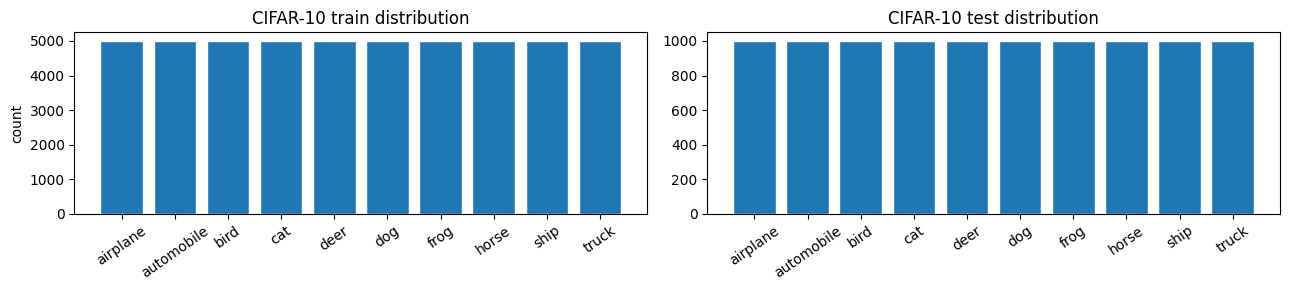

Train counts: {'airplane': 5000, 'automobile': 5000, 'bird': 5000, 'cat': 5000, 'deer': 5000, 'dog': 5000, 'frog': 5000, 'horse': 5000, 'ship': 5000, 'truck': 5000}
Test counts : {'airplane': 1000, 'automobile': 1000, 'bird': 1000, 'cat': 1000, 'deer': 1000, 'dog': 1000, 'frog': 1000, 'horse': 1000, 'ship': 1000, 'truck': 1000}


In [88]:
counts_raw = np.bincount(y_train_raw, minlength=N_CLASSES)
counts_test = np.bincount(y_test, minlength=N_CLASSES)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 3))

ax1.bar(CIFAR_NAMES, counts_raw, edgecolor='white')
ax1.set_title('CIFAR-10 train distribution')
ax1.set_ylabel('count')
ax1.tick_params(axis='x', rotation=35)

ax2.bar(CIFAR_NAMES, counts_test, edgecolor='white')
ax2.set_title('CIFAR-10 test distribution')
ax2.tick_params(axis='x', rotation=35)

plt.tight_layout()
plt.show()

print('Train counts:', dict(zip(CIFAR_NAMES, counts_raw.tolist())))
print('Test counts :', dict(zip(CIFAR_NAMES, counts_test.tolist())))


## Train/validation split

Validation is stratified so each class contributes the same fraction. The test set remains untouched until the final evaluation.


In [89]:
def stratified_train_val_split(X, y, val_frac=0.10, seed=123):
    rng = np.random.default_rng(seed)
    train_idx = []
    val_idx = []

    for c in range(N_CLASSES):
        idx = np.where(y == c)[0].copy()
        rng.shuffle(idx)
        n_val = max(1, int(len(idx) * val_frac))
        val_idx.append(idx[:n_val])
        train_idx.append(idx[n_val:])

    train_idx = np.concatenate(train_idx)
    val_idx = np.concatenate(val_idx)
    rng.shuffle(train_idx)
    rng.shuffle(val_idx)
    return X[train_idx], y[train_idx], X[val_idx], y[val_idx]


if TRAIN_SUBSET is not None:
    rng_subset = np.random.default_rng(111)
    keep = []
    per_class = max(1, TRAIN_SUBSET // N_CLASSES)
    for c in range(N_CLASSES):
        idx = np.where(y_train_raw == c)[0]
        keep.append(rng_subset.choice(idx, size=min(per_class, len(idx)), replace=False))
    keep = np.concatenate(keep)
    rng_subset.shuffle(keep)
    X_for_split = X_train_raw[keep]
    y_for_split = y_train_raw[keep]
else:
    X_for_split = X_train_raw
    y_for_split = y_train_raw

X_train_raw_fit, y_train, X_val_raw, y_val = stratified_train_val_split(
    X_for_split, y_for_split, val_frac=VAL_FRAC, seed=123
)

Y_train = one_hot(y_train, classes=N_CLASSES)
Y_val = one_hot(y_val, classes=N_CLASSES)
Y_test = one_hot(y_test, classes=N_CLASSES)

print(f'Train-fit raw : {X_train_raw_fit.shape}')
print(f'Validation    : {X_val_raw.shape}')
print(f'Test          : {X_test_raw.shape}')


Train-fit raw : (45000, 3072)
Validation    : (5000, 3072)
Test          : (10000, 3072)


## Preprocessing

The paper used exact ZCA preprocessing for SVHN and CIFAR-10. This notebook includes ZCA, but defaults to per-pixel standardization because it is much faster and is usually enough to stress the vectorized micrograd implementation.

For paper-style ZCA, set:

```python
PREPROCESSING = 'zca'
ZCA_FIT_N = None     # exact full train-fit covariance; slower
```

A compromise is `ZCA_FIT_N = 10_000`, which fits the whitening transform on a subset.


In [90]:
def fit_standardizer(X):
    mean = X.mean(axis=0, keepdims=True)
    std = X.std(axis=0, keepdims=True) + 1e-6
    return mean, std


def fit_zca(X, eps=1e-3, fit_n=None, seed=0):
    rng = np.random.default_rng(seed)
    if fit_n is not None and fit_n < len(X):
        idx = rng.choice(len(X), size=fit_n, replace=False)
        X_fit = X[idx]
    else:
        X_fit = X

    print(f'Fitting ZCA on {len(X_fit):,} examples with {X_fit.shape[1]:,} features ...')
    t0 = perf_counter()

    mean = X_fit.mean(axis=0, keepdims=True)
    Xc = X_fit - mean
    cov = (Xc.T @ Xc) / len(Xc)

    # eigh is for symmetric matrices. Sort descending for easier inspection.
    eigvals, eigvecs = np.linalg.eigh(cov)
    order = np.argsort(eigvals)[::-1]
    eigvals = eigvals[order]
    eigvecs = eigvecs[:, order]

    W = (eigvecs * (1.0 / np.sqrt(eigvals + eps))) @ eigvecs.T
    print(f'ZCA fit took {perf_counter() - t0:.1f}s')
    return mean.astype(np.float32), W.astype(np.float32), eigvals.astype(np.float32)


if PREPROCESSING == 'standardize':
    X_mean, X_std = fit_standardizer(X_train_raw_fit)

    def normalize_X(X):
        return (X - X_mean) / X_std

    zca_eigvals = None

elif PREPROCESSING == 'zca':
    X_mean, ZCA_W, zca_eigvals = fit_zca(X_train_raw_fit, eps=ZCA_EPS, fit_n=ZCA_FIT_N, seed=123)

    def normalize_X(X):
        return (X - X_mean) @ ZCA_W

else:
    raise ValueError("PREPROCESSING must be 'standardize' or 'zca'")

X_val = normalize_X(X_val_raw)
X_test = normalize_X(X_test_raw)

norm_train_sample = normalize_X(X_train_raw_fit[: min(5000, len(X_train_raw_fit))])
print(f'Preprocessing: {PREPROCESSING}')
print(f'Norm check on sample: mean={norm_train_sample.mean():.3f}, std={norm_train_sample.std():.3f}')


Preprocessing: standardize
Norm check on sample: mean=0.000, std=0.999


## A look at the data

CIFAR-10 examples are tiny, color, and highly varied. A raw-pixel MLP has no translation equivariance or local weight sharing, so it is expected to underperform a CNN. That limitation is useful here: it makes the notebook a stress test of dense vectorized autodiff, not a benchmark-chasing exercise.


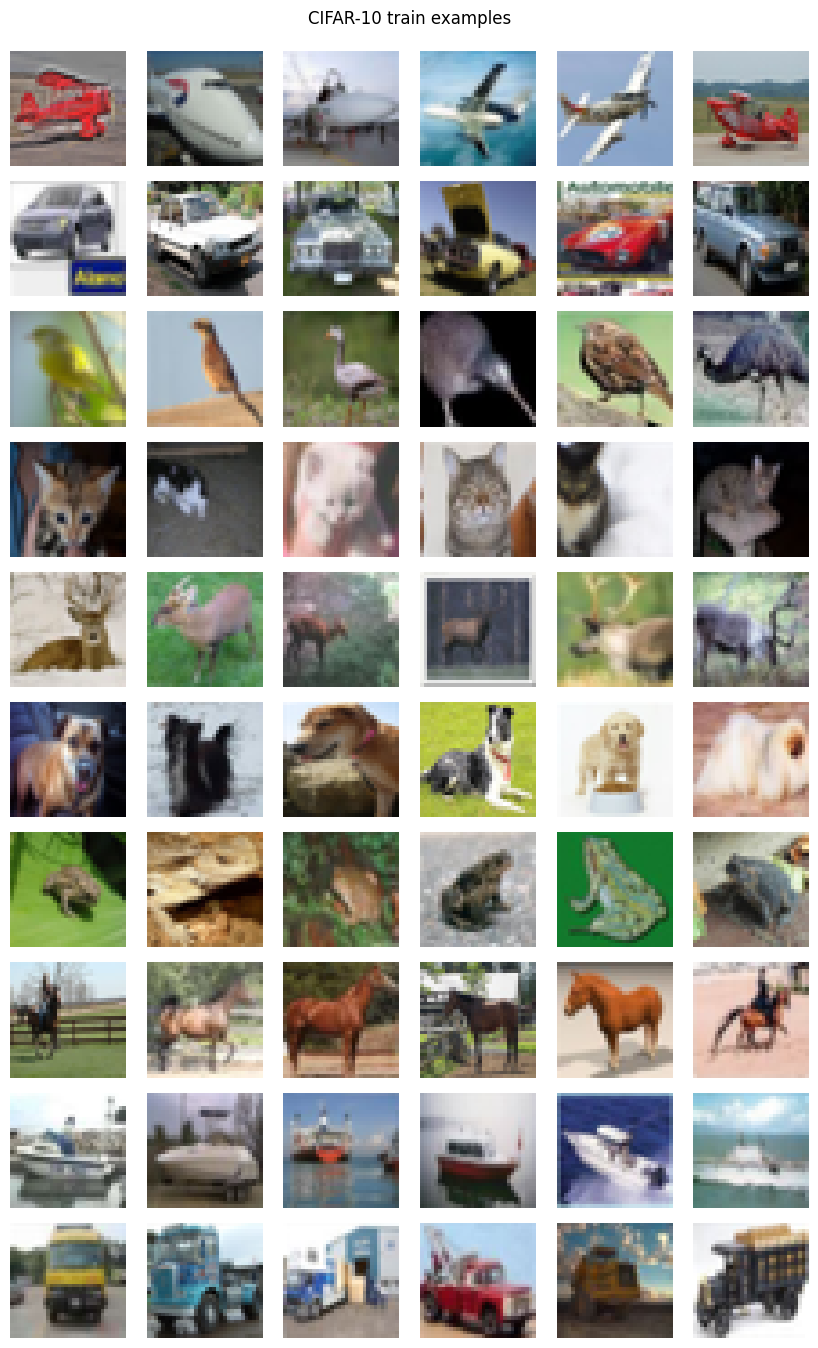

In [91]:
show_cifar_grid(X_train_raw_fit, y_train, CIFAR_NAMES, n_per_class=6, seed=3, title='CIFAR-10 train examples')


## Batch augmentation

For CIFAR-10, horizontal flips and small random crops are standard. Vertical flips are available as a knob but default to zero because many CIFAR-10 classes have a meaningful upright orientation.

The augmentation is done on raw `[0, 1]` images, then the batch is standardized or whitened before the MLP sees it.


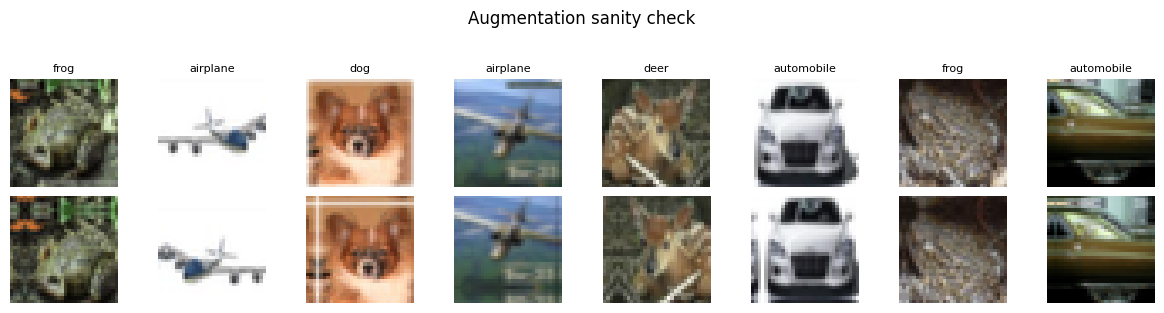

In [92]:
def augment_batch_cifar10(Xb, rng, p_flip=0.5, p_vflip=0.0, pad=4, noise_std=0.0):
    """Light CIFAR-10 augmentation for flattened channel-first arrays.

    Parameters
    ----------
    Xb : array, shape (batch, 3072), raw pixels in [0, 1]
    p_flip : probability of horizontal flip
    p_vflip : probability of vertical flip; off by default for CIFAR-10
    pad : random crop padding in pixels; pad=4 is common for CIFAR-10
    noise_std : optional pixel Gaussian noise
    """
    imgs = flat_to_images(Xb).copy()
    out = np.empty_like(imgs)

    for i, img in enumerate(imgs):
        if pad > 0:
            padded = np.pad(img, ((pad, pad), (pad, pad), (0, 0)), mode='reflect')
            top = rng.integers(0, 2 * pad + 1)
            left = rng.integers(0, 2 * pad + 1)
            img = padded[top:top + 32, left:left + 32, :]

        if rng.random() < p_flip:
            img = img[:, ::-1, :]

        if rng.random() < p_vflip:
            img = img[::-1, :, :]

        out[i] = img

    if noise_std > 0:
        out += rng.normal(0.0, noise_std, size=out.shape)

    out = np.clip(out, 0.0, 1.0)
    return images_to_flat(out)


# Visual check: one row before augmentation, one row after augmentation.
rng_aug_show = np.random.default_rng(5)
idx_show = rng_aug_show.choice(len(X_train_raw_fit), size=8, replace=False)
X_show = X_train_raw_fit[idx_show]
X_show_aug = augment_batch_cifar10(X_show, rng_aug_show, p_flip=0.5, pad=4, noise_std=0.0)

fig, axes = plt.subplots(2, 8, figsize=(12, 3))
for j in range(8):
    axes[0, j].imshow(flat_to_images(X_show[j:j+1])[0])
    axes[0, j].axis('off')
    axes[0, j].set_title(CIFAR_NAMES[y_train[idx_show[j]]], fontsize=8)

    axes[1, j].imshow(flat_to_images(X_show_aug[j:j+1])[0])
    axes[1, j].axis('off')

axes[0, 0].set_ylabel('raw', rotation=0, ha='right', va='center')
axes[1, 0].set_ylabel('aug', rotation=0, ha='right', va='center')
plt.suptitle('Augmentation sanity check', y=1.03)
plt.tight_layout()
plt.show()


## Model

A two-hidden-layer ReLU MLP:

```text
3072  →  768  →  384  →  10
          ReLU    ReLU    linear logits
```

This model is deliberately dense. The first weight matrix alone is `3072 × 768`, which is a good stress test for the vectorized `Value.__matmul__` backward path.


In [93]:
np.random.seed(42)

hidden_sizes = HIDDEN_BY_PROFILE[WIDTH_PROFILE]
model = MLP(N_FEATURES, hidden_sizes)

n_params = sum(p.data.size for p in model.parameters())
print(model)
print(f'Scalar parameters : {n_params:,}')
print(f'Value nodes       : {len(model.parameters())}  '
      f'(vs ~{n_params:,} scalar nodes in scalar micrograd)')


MLP of [Layer(3072, 768), Layer(768, 384), Layer(384, 10)]
Scalar parameters : 2,659,210
Value nodes       : 6  (vs ~2,659,210 scalar nodes in scalar micrograd)


## Evaluation helpers

Validation and test evaluation are done in mini-batches to avoid building a large temporary computation graph for all 10 000 images at once.


In [94]:
def logits_batched(model, X, batch_size=1024):
    parts = []
    for start in range(0, len(X), batch_size):
        xb = X[start:start + batch_size]
        logits = model(Value(xb, requires_grad=False))
        parts.append(logits.data.copy())
    return np.concatenate(parts, axis=0)


def softmax_np(logits):
    z = logits - logits.max(axis=1, keepdims=True)
    exp_z = np.exp(z)
    return exp_z / exp_z.sum(axis=1, keepdims=True)


def ce_from_logits_np(logits, Y):
    probs = softmax_np(logits)
    loss = -(np.log(probs.clip(1e-7)) * Y).sum(axis=1).mean()
    acc = float((probs.argmax(axis=1) == Y.argmax(axis=1)).mean())
    return float(loss), acc


def evaluate_model(model, X, Y, batch_size=1024):
    logits = logits_batched(model, X, batch_size=batch_size)
    loss, acc = ce_from_logits_np(logits, Y)
    return loss, acc, logits


## Mini-batch sampler

CIFAR-10 is balanced, so ordinary natural-frequency sampling is fine. The `replace=True` sampler keeps each optimization step independent.


In [95]:
def sample_batch_indices(n, batch_size, rng, replace=True):
    if replace:
        return rng.integers(0, n, size=batch_size)
    return rng.choice(n, size=batch_size, replace=False)


## One-step timing check

This cell times a single forward/backward/update pass. It is a quick way to check whether the chosen width profile and batch size are reasonable on your machine before committing to the full loop.


In [96]:
def time_one_training_step(model, rng, batch_size=BATCH_SIZE):
    ri = sample_batch_indices(len(y_train), batch_size, rng)
    Xb_raw = X_train_raw_fit[ri]
    Yb = Y_train[ri]
    Xb_aug = augment_batch_cifar10(Xb_raw, rng, p_flip=0.5, p_vflip=0.0, pad=4, noise_std=0.0)
    Xb = normalize_X(Xb_aug)

    t0 = perf_counter()
    loss, acc = cross_entropy_loss(model, Xb, Yb, alpha=L2_ALPHA)
    optimizer_tmp = Adam(model.parameters(), lr=LR, total_steps=1, weight_decay=WEIGHT_DECAY)
    optimizer_tmp.zero_grad()
    loss.backward()
    optimizer_tmp.step(0)
    dt = perf_counter() - t0
    return dt, loss.item(), acc


# This mutates the model by one step. Run it before training only if you want the timing check.
RUN_TIMING_CHECK = False
if RUN_TIMING_CHECK:
    dt, loss0, acc0 = time_one_training_step(model, np.random.default_rng(99))
    print(f'one training step: {dt * 1000:.1f} ms | loss={loss0:.4f} | acc={acc0:.2%}')
else:
    print('Timing check skipped. Set RUN_TIMING_CHECK=True to run it.')


Timing check skipped. Set RUN_TIMING_CHECK=True to run it.


## EMA-smoothed training loop

The selection rule is intentionally conservative:

```python
ACC_TOL = 0.005

if val_acc > best_val_acc + ACC_TOL:
    improved = True
elif val_acc >= best_val_acc - ACC_TOL and val_loss < best_val_loss:
    improved = True
```

So a checkpoint can replace the previous one either by clearly improving accuracy or by matching accuracy within half a percentage point while lowering validation loss.


In [97]:
def copy_checkpoint(ckpt):
    return [x.copy() for x in ckpt]


def update_ema_checkpoint(model, ema_checkpoint, decay=0.995):
    """ema = decay * ema + (1 - decay) * current_params"""
    for ema_param, p in zip(ema_checkpoint, model.parameters()):
        ema_param *= decay
        ema_param += (1.0 - decay) * p.data


optimizer = Adam(model.parameters(), lr=LR, total_steps=STEPS, weight_decay=WEIGHT_DECAY)

best_checkpoint = None
best_val_acc = -1.0
best_val_loss = float('inf')
best_step = -1

ema_checkpoint = None
history = []   # (step, batch_loss, batch_acc, val_loss, val_acc)

rng = np.random.default_rng(7)

t_train = perf_counter()

for k in range(STEPS):
    ri = sample_batch_indices(len(y_train), BATCH_SIZE, rng, replace=True)

    Xb_raw = X_train_raw_fit[ri]
    Yb = Y_train[ri]

    Xb_raw = augment_batch_cifar10(Xb_raw, rng, p_flip=0.5, p_vflip=0.0, pad=4, noise_std=0.0)
    Xb = normalize_X(Xb_raw)

    batch_loss, batch_acc = cross_entropy_loss(model, Xb, Yb, alpha=L2_ALPHA)

    optimizer.zero_grad()
    batch_loss.backward()
    optimizer.step(k)

    if k == EMA_START:
        ema_checkpoint = save_checkpoint(model)
    elif k > EMA_START:
        update_ema_checkpoint(model, ema_checkpoint, decay=EMA_DECAY)

    if k % EVAL_EVERY == 0 or k == STEPS - 1:
        if ema_checkpoint is not None:
            current_checkpoint = save_checkpoint(model)
            load_checkpoint(model, ema_checkpoint)
            val_loss, val_acc, _ = evaluate_model(model, X_val, Y_val, batch_size=1024)
            candidate_checkpoint = save_checkpoint(model)
            load_checkpoint(model, current_checkpoint)
        else:
            val_loss, val_acc, _ = evaluate_model(model, X_val, Y_val, batch_size=1024)
            candidate_checkpoint = save_checkpoint(model)

        history.append((k, batch_loss.item(), batch_acc, val_loss, val_acc))

        print(
            f"step {k:5d}  "
            f"batch loss {batch_loss.item():.4f}  "
            f"batch acc {batch_acc:.2%}  "
            f"ema val loss {val_loss:.4f}  "
            f"ema val acc {val_acc:.2%}"
        )

        ACC_TOL = 0.005
        improved = False
        if val_acc > best_val_acc + ACC_TOL:
            improved = True
        elif val_acc >= best_val_acc - ACC_TOL and val_loss < best_val_loss:
            improved = True

        if improved:
            best_val_acc = val_acc
            best_val_loss = val_loss
            best_step = k
            best_checkpoint = copy_checkpoint(candidate_checkpoint)

print()
print(f'Training time: {(perf_counter() - t_train) / 60:.1f} min')
print(
    f"Best EMA checkpoint at step {best_step}, "
    f"val acc {best_val_acc:.2%}, "
    f"val loss {best_val_loss:.4f}"
)


step     0  batch loss 5.4286  batch acc 7.03%  ema val loss 2.5625  ema val acc 18.94%
step   100  batch loss 3.9676  batch acc 41.80%  ema val loss 1.6920  ema val acc 41.18%
step   200  batch loss 3.8375  batch acc 42.19%  ema val loss 1.6038  ema val acc 44.46%
step   300  batch loss 3.5376  batch acc 45.31%  ema val loss 1.5495  ema val acc 45.96%
step   400  batch loss 3.4294  batch acc 41.41%  ema val loss 1.5222  ema val acc 46.22%
step   500  batch loss 3.3124  batch acc 42.97%  ema val loss 1.4931  ema val acc 48.02%
step   600  batch loss 3.2069  batch acc 39.84%  ema val loss 1.4489  ema val acc 49.40%
step   700  batch loss 2.9692  batch acc 44.53%  ema val loss 1.4183  ema val acc 50.50%
step   800  batch loss 2.8673  batch acc 43.75%  ema val loss 1.3993  ema val acc 51.52%
step   900  batch loss 2.7310  batch acc 48.44%  ema val loss 1.3858  ema val acc 51.96%
step  1000  batch loss 2.6500  batch acc 46.48%  ema val loss 1.3720  ema val acc 52.86%
step  1100  batch loss

## Training curves

The validation curves should be smoother than the batch curves. Batch accuracy is noisy because every step sees a freshly augmented random mini-batch.


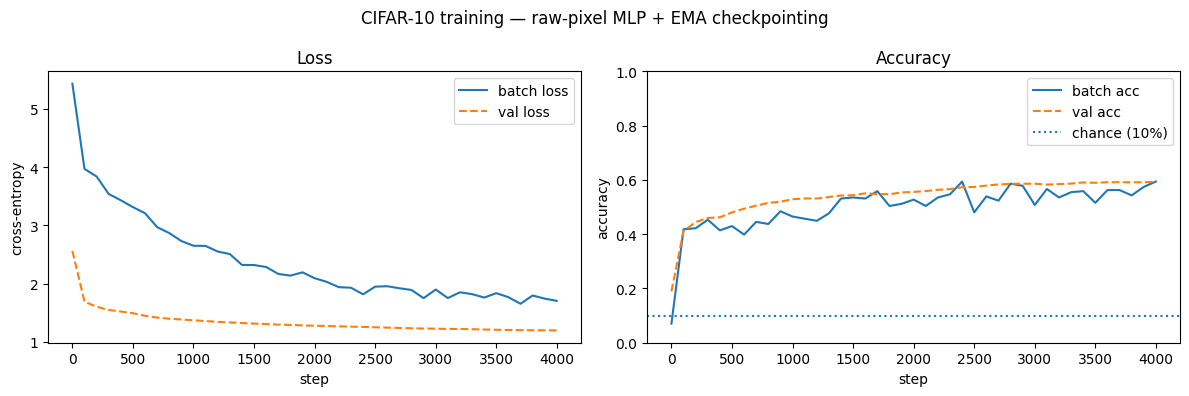

In [98]:
hist = np.array(history)
steps_logged = hist[:, 0]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(steps_logged, hist[:, 1], label='batch loss')
ax1.plot(steps_logged, hist[:, 3], label='val loss', linestyle='--')
ax1.set_xlabel('step')
ax1.set_ylabel('cross-entropy')
ax1.set_title('Loss')
ax1.legend()

ax2.plot(steps_logged, hist[:, 2], label='batch acc')
ax2.plot(steps_logged, hist[:, 4], label='val acc', linestyle='--')
ax2.axhline(1 / N_CLASSES, linestyle=':', label=f'chance ({1/N_CLASSES:.0%})')
ax2.set_xlabel('step')
ax2.set_ylabel('accuracy')
ax2.set_ylim(0, 1)
ax2.set_title('Accuracy')
ax2.legend()

plt.suptitle('CIFAR-10 training — raw-pixel MLP + EMA checkpointing')
plt.tight_layout()
plt.show()


## Test-set evaluation

Restore the best validation checkpoint and evaluate once on the official test set. The test set is not used for training or checkpoint selection.


In [99]:
load_checkpoint(model, best_checkpoint)

test_loss, test_acc, test_logits = evaluate_model(model, X_test, Y_test, batch_size=1024)
test_preds = test_logits.argmax(axis=1)

print(f'Restored checkpoint from step {best_step}')
print(f'Test loss     : {test_loss:.4f}')
print(f'Test accuracy : {test_acc:.2%}  '
      f'({int(test_acc * len(y_test)):,} / {len(y_test):,} correct)')
print(f'Chance baseline : {1/N_CLASSES:.2%}')


Restored checkpoint from step 3999
Test loss     : 1.2051
Test accuracy : 58.20%  (5,820 / 10,000 correct)
Chance baseline : 10.00%


## Confusion matrix

The main raw-pixel MLP confusions are usually among visually similar animals, and among automobiles/trucks or ships/airplanes depending on the run.


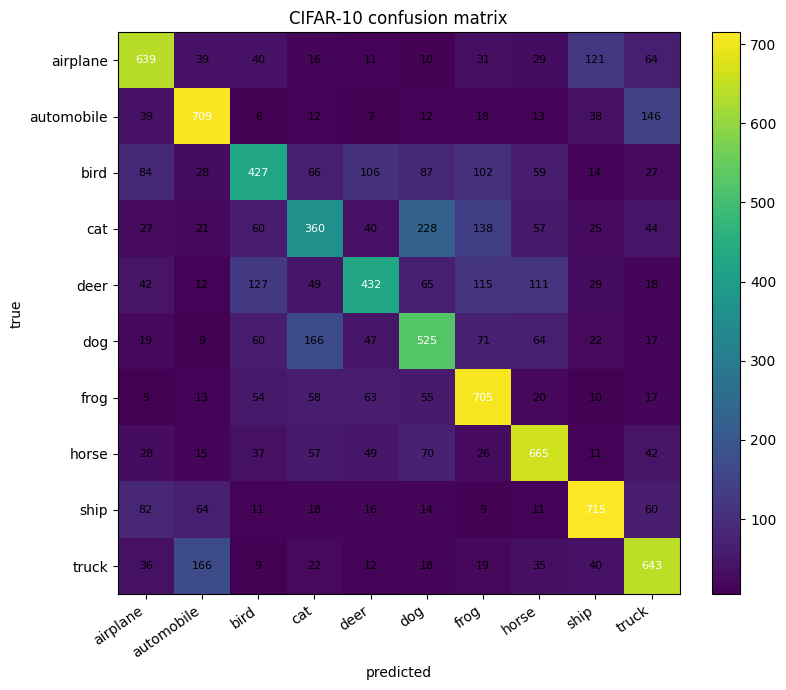

In [100]:
C = np.zeros((N_CLASSES, N_CLASSES), dtype=int)
for true, pred in zip(y_test, test_preds):
    C[true, pred] += 1

fig, ax = plt.subplots(figsize=(8, 7))
im = ax.imshow(C)
plt.colorbar(im, ax=ax, fraction=0.046)

ax.set_xticks(range(N_CLASSES))
ax.set_yticks(range(N_CLASSES))
ax.set_xticklabels(CIFAR_NAMES, rotation=35, ha='right')
ax.set_yticklabels(CIFAR_NAMES)
ax.set_xlabel('predicted')
ax.set_ylabel('true')
ax.set_title('CIFAR-10 confusion matrix')

for i in range(N_CLASSES):
    for j in range(N_CLASSES):
        color = 'white' if C[i, j] > C.max() / 2 else 'black'
        ax.text(j, i, str(C[i, j]), ha='center', va='center', fontsize=8, color=color)

plt.tight_layout()
plt.show()


## Per-class accuracy

Since the test set is balanced, overall accuracy is the mean of the class accuracies. A raw-pixel MLP often does better on classes with distinctive global color/shape cues, such as ships or trucks, and worse on animal classes.


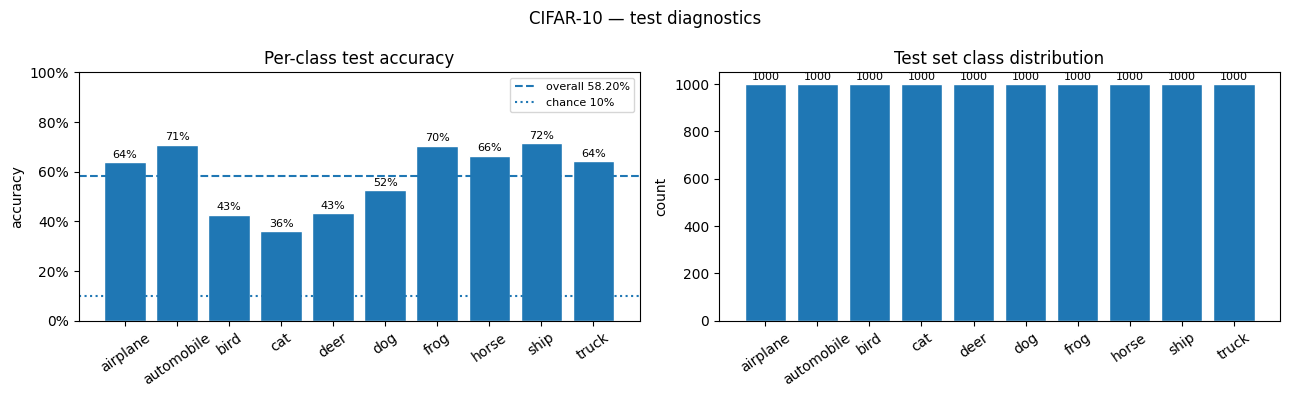

In [101]:
per_class = [
    float((test_preds[y_test == c] == c).mean())
    for c in range(N_CLASSES)
]

test_counts = np.bincount(y_test, minlength=N_CLASSES)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

bars = ax1.bar(CIFAR_NAMES, per_class, edgecolor='white')
ax1.axhline(test_acc, linestyle='--', label=f'overall {test_acc:.2%}')
ax1.axhline(1 / N_CLASSES, linestyle=':', label=f'chance {1/N_CLASSES:.0%}')
ax1.set_ylim(0, 1)
ax1.set_ylabel('accuracy')
ax1.set_title('Per-class test accuracy')
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:.0%}'))
ax1.tick_params(axis='x', rotation=35)
ax1.legend(fontsize=8)
for bar, v in zip(bars, per_class):
    ax1.text(bar.get_x() + bar.get_width() / 2, v + 0.01,
             f'{v:.0%}', ha='center', va='bottom', fontsize=8)

ax2.bar(CIFAR_NAMES, test_counts, edgecolor='white')
ax2.set_ylabel('count')
ax2.set_title('Test set class distribution')
ax2.tick_params(axis='x', rotation=35)
for bar, v in zip(ax2.patches, test_counts):
    ax2.text(bar.get_x() + bar.get_width() / 2, v + 10,
             str(v), ha='center', va='bottom', fontsize=8)

plt.suptitle('CIFAR-10 — test diagnostics')
plt.tight_layout()
plt.show()


## Hard cases — misclassified images

A random sample of mistakes. CIFAR-10 is tiny enough that many failures are understandable even for a human viewer.


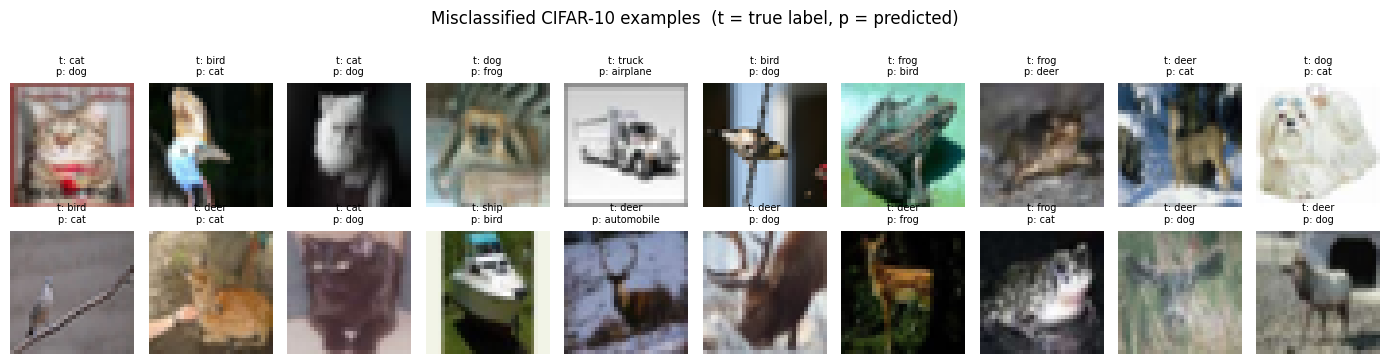

4180 misclassifications out of 10000 test images


In [102]:
wrong_idx = np.where(test_preds != y_test)[0]

if len(wrong_idx) == 0:
    print('No misclassifications found.')
else:
    n_show = min(20, len(wrong_idx))
    show = np.random.default_rng(1).choice(wrong_idx, size=n_show, replace=False)

    ncols = 10
    nrows = int(np.ceil(n_show / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(14, 1.8 * nrows))
    axes = np.atleast_1d(axes).ravel()

    imgs = flat_to_images(X_test_raw[show])
    for ax, img, i in zip(axes, imgs, show):
        ax.imshow(np.clip(img, 0, 1))
        t = CIFAR_NAMES[y_test[i]]
        p = CIFAR_NAMES[test_preds[i]]
        ax.set_title(f't: {t}\np: {p}', fontsize=7)
        ax.axis('off')

    for ax in axes[n_show:]:
        ax.axis('off')

    plt.suptitle('Misclassified CIFAR-10 examples  (t = true label, p = predicted)', y=1.02)
    plt.tight_layout()
    plt.show()

    print(f'{len(wrong_idx)} misclassifications out of {len(y_test)} test images')


## Softmax probability distributions

For a few correct and incorrect predictions, the bars show the model's full softmax distribution. A confident wrong prediction is often more informative than a low-confidence miss.


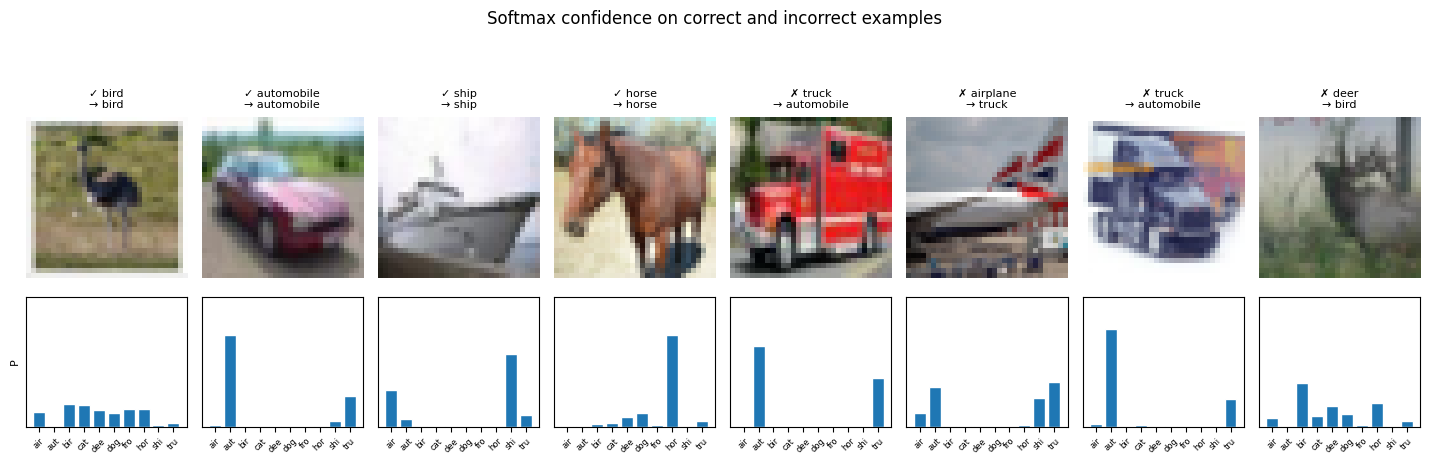

In [103]:
probs_all = softmax_np(test_logits)
correct_idx = np.where(test_preds == y_test)[0]
incorrect_idx = np.where(test_preds != y_test)[0]

rng_show = np.random.default_rng(3)
n_correct = min(4, len(correct_idx))
n_incorrect = min(4, len(incorrect_idx))
show_correct = rng_show.choice(correct_idx, size=n_correct, replace=False) if n_correct else np.array([], dtype=int)
show_incorrect = rng_show.choice(incorrect_idx, size=n_incorrect, replace=False) if n_incorrect else np.array([], dtype=int)
show_all = np.concatenate([show_correct, show_incorrect])

if len(show_all) == 0:
    print('No examples to show.')
else:
    fig, axes = plt.subplots(2, len(show_all), figsize=(1.8 * len(show_all), 4.5),
                             gridspec_kw={'height_ratios': [2, 1]})
    if len(show_all) == 1:
        axes = axes.reshape(2, 1)

    for col, i in enumerate(show_all):
        axes[0, col].imshow(flat_to_images(X_test_raw[i:i+1])[0])
        axes[0, col].axis('off')
        correct = (test_preds[i] == y_test[i])
        title_mark = '✓' if correct else '✗'
        axes[0, col].set_title(
            f"{title_mark} {CIFAR_NAMES[y_test[i]]}\n→ {CIFAR_NAMES[test_preds[i]]}",
            fontsize=8,
        )

        axes[1, col].bar(range(N_CLASSES), probs_all[i], edgecolor='white')
        axes[1, col].set_ylim(0, 1)
        axes[1, col].set_xticks(range(N_CLASSES))
        axes[1, col].set_xticklabels([n[:3] for n in CIFAR_NAMES], fontsize=6, rotation=45)
        axes[1, col].set_yticks([])
        if col == 0:
            axes[1, col].set_ylabel('P', fontsize=8)

    plt.suptitle('Softmax confidence on correct and incorrect examples', y=1.02)
    plt.tight_layout()
    plt.show()


## Notes and next experiments

This notebook intentionally stays within the current `vect_micrograd` abstraction. Good follow-ups:

1. **Try ZCA whitening**: set `PREPROCESSING='zca'`, reduce `BATCH_SIZE` if needed, and compare validation curves.
2. **Width vs depth**: try `WIDTH_PROFILE='wide'` before adding many more layers. Deep raw-pixel ReLU MLPs can stagnate without normalization layers or residual connections.
3. **Augmentation strength**: random crop + horizontal flip is usually safe; vertical flips are off by default because they can change CIFAR-10 semantics.
4. **CNN support**: a competitive CIFAR-10 model should use convolutions. That requires new autograd ops for convolution/pooling or lowering convolution to matrix multiplication, which is outside the current small MLP engine.
